# analysis of our users

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
user_features = pd.read_csv("data/data_preprocessed/user_features.csv")

In [4]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'sign_up_year', 'states',
       'num_session', 'num_trips', 'num_flights', 'num_hotels',
       'booking_discount_rate', 'average_seats', 'average_checked_bags',
       'average_seats_price', 'weekend_trip_ratio', 'average_nights',
       'total_flight_cost', 'total_hotels_cost', 'avg_clicks',
       'avg_distance_user', 'clicks_per_min', 'avg_session_dauer'],
      dtype='str')

In [5]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_checked_bags,average_seats_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer
0,94883,F,True,False,usa,kansas city,MCI,54,2022,Missouri,...,1.0,932.630000,0.500000,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111
1,101486,F,True,True,usa,tacoma,TCM,53,2022,Washington,...,0.5,180.130000,0.666667,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308
2,101961,F,True,False,usa,boston,BOS,46,2022,Massachusetts,...,0.5,321.533333,0.142857,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944
3,106907,F,True,True,usa,miami,TNT,47,2022,Florida,...,1.0,165.510000,0.000000,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858
4,118043,F,False,True,usa,los angeles,LAX,54,2022,California,...,1.0,445.847222,0.250000,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,52,2023,California,...,0.0,448.535000,0.000000,1.000000,1122.1060,220.00,15.500000,609.885174,8.034557,1.929167
5778,785186,F,True,True,usa,little rock,LIT,47,2023,Arkansas,...,0.0,176.675000,1.000000,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417
5779,792549,F,False,False,usa,kansas city,MCI,48,2023,Missouri,...,0.5,259.792500,1.000000,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250
5780,811077,F,True,True,usa,knoxville,TYS,47,2023,Tennessee,...,0.0,579.790000,0.000000,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083


In [6]:
user_features["age"] = user_features["age"] - 3 # ups

# age vs. weekend trip ratio

In [7]:
user_features["age"].nunique()

71

<Axes: xlabel='age', ylabel='weekend_trip_ratio'>

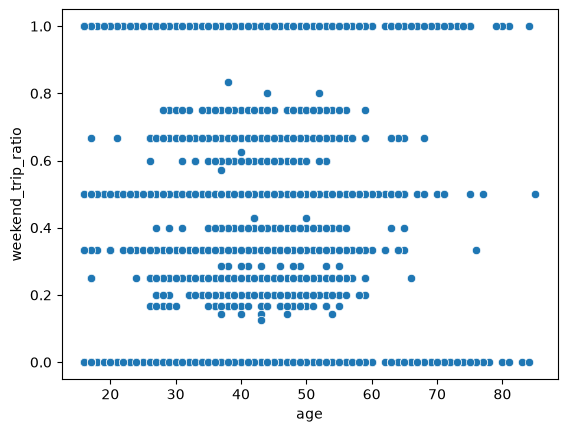

In [8]:
sns.scatterplot(user_features, x="age", y="weekend_trip_ratio")

<Axes: xlabel='age', ylabel='weekend_trip_ratio'>

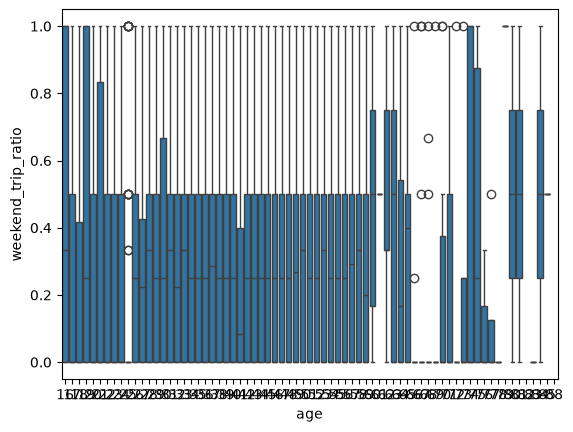

In [9]:
sns.boxplot(user_features, x="age", y="weekend_trip_ratio")

In [10]:
# Age

# Clicks analyse

In [11]:
user_features["avg_clicks"].isna().sum()

np.int64(0)

<Axes: xlabel='avg_clicks', ylabel='Count'>

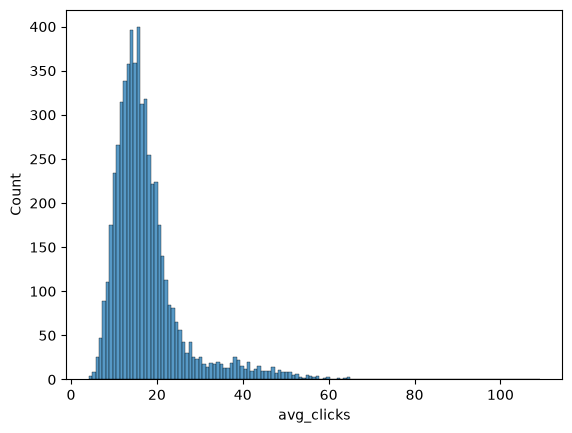

In [12]:
sns.histplot(user_features, x="avg_clicks")

# clicks_per_min vs avg_session_dauer (Kunden-Aktivität)

<Axes: xlabel='avg_session_dauer', ylabel='clicks_per_min'>

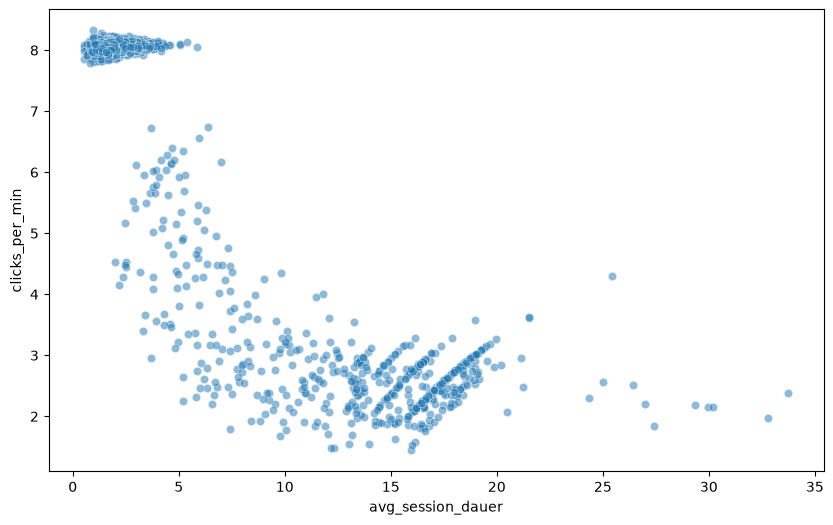

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=user_features,
    x="avg_session_dauer",
    y="clicks_per_min",
    alpha=0.5
)

# Anzahl der Trips als Farbe

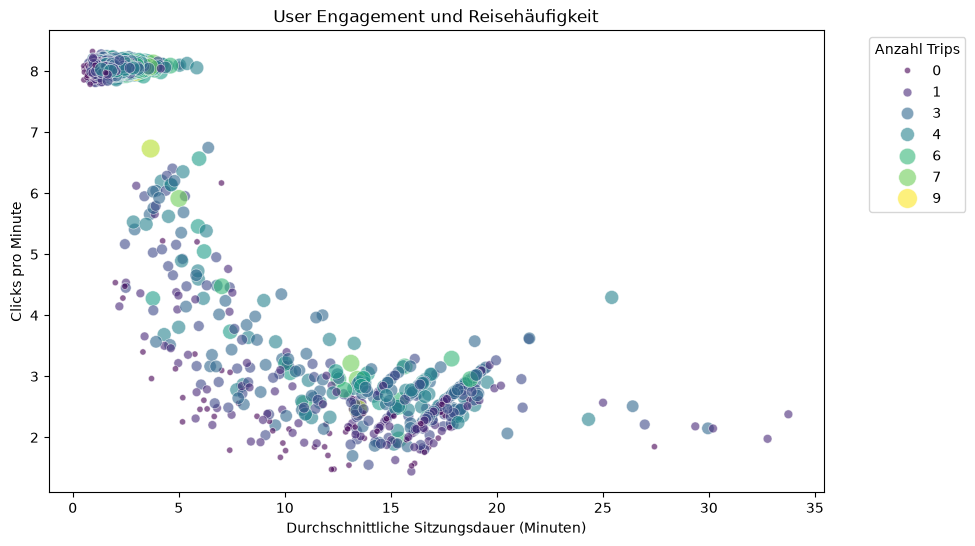

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=user_features,
    x="avg_session_dauer",
    y="clicks_per_min",
    hue="num_trips",
    size="num_trips",
    sizes=(20, 200),
    alpha=0.6,
    palette="viridis"
)

plt.title("User Engagement und Reisehäufigkeit")
plt.xlabel("Durchschnittliche Sitzungsdauer (Minuten)")
plt.ylabel("Clicks pro Minute")
plt.legend(title="Anzahl Trips", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()


# Wie weit reisen die User

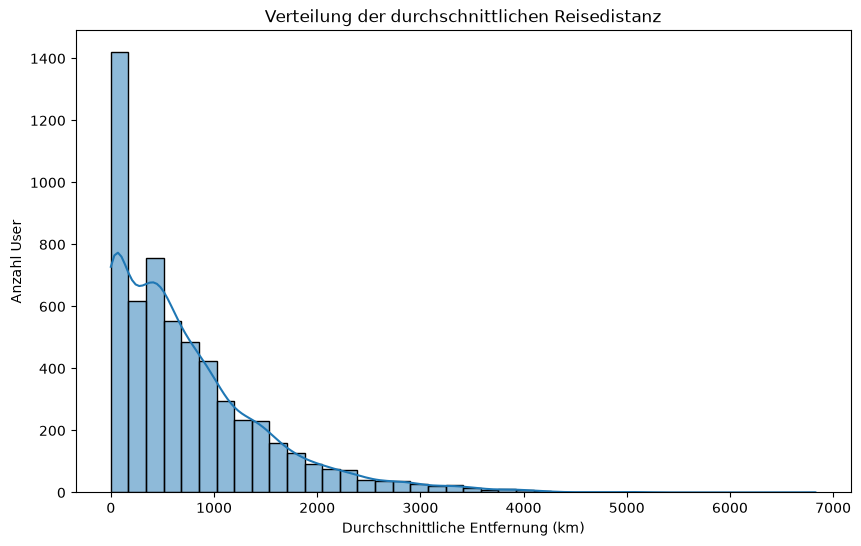

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.histplot(
    data=user_features,
    x="avg_distance_user",
    bins=40,
    kde=True
)

plt.title("Verteilung der durchschnittlichen Reisedistanz")
plt.xlabel("Durchschnittliche Entfernung (km)")
plt.ylabel("Anzahl User")

plt.show()


# Reisedistanz vs. Anzahl Trips

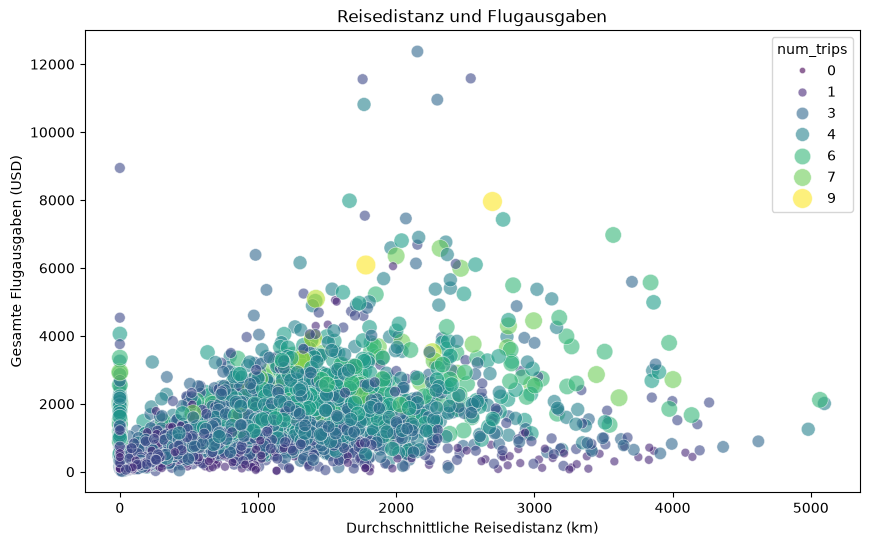

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=user_features,
    x="avg_distance_user",
    y="total_flight_cost",
    hue="num_trips",
    size="num_trips",
    sizes=(20, 200),
    alpha=0.6,
    palette="viridis"
)

plt.title("Reisedistanz und Flugausgaben")
plt.xlabel("Durchschnittliche Reisedistanz (km)")
plt.ylabel("Gesamte Flugausgaben (USD)")

plt.show()


# Age analysis

<Axes: xlabel='age', ylabel='Count'>

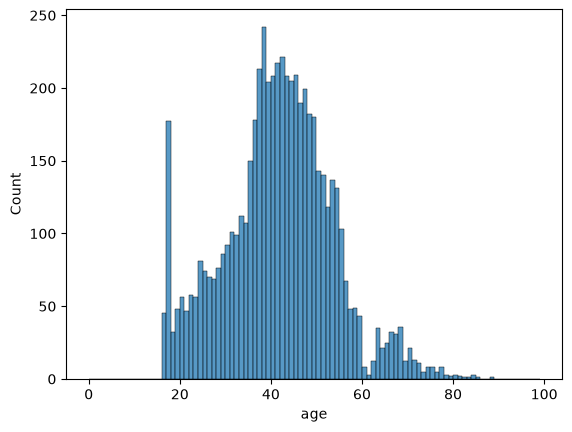

In [17]:
sns.histplot(user_features, x="age", bins=range(0, 100, 1))

<Axes: xlabel='gender', ylabel='percent'>

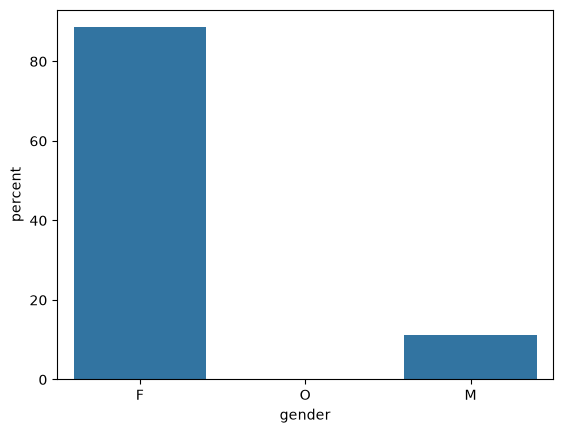

In [18]:
sns.countplot(user_features, x="gender", stat="percent")

In [19]:
user_features["gender"].value_counts()

gender
F    5118
M     653
O      11
Name: count, dtype: int64

# spent analysis

In [20]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'sign_up_year', 'states',
       'num_session', 'num_trips', 'num_flights', 'num_hotels',
       'booking_discount_rate', 'average_seats', 'average_checked_bags',
       'average_seats_price', 'weekend_trip_ratio', 'average_nights',
       'total_flight_cost', 'total_hotels_cost', 'avg_clicks',
       'avg_distance_user', 'clicks_per_min', 'avg_session_dauer'],
      dtype='str')

In [21]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_checked_bags,average_seats_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer
0,94883,F,True,False,usa,kansas city,MCI,51,2022,Missouri,...,1.0,932.630000,0.500000,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111
1,101486,F,True,True,usa,tacoma,TCM,50,2022,Washington,...,0.5,180.130000,0.666667,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308
2,101961,F,True,False,usa,boston,BOS,43,2022,Massachusetts,...,0.5,321.533333,0.142857,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944
3,106907,F,True,True,usa,miami,TNT,44,2022,Florida,...,1.0,165.510000,0.000000,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858
4,118043,F,False,True,usa,los angeles,LAX,51,2022,California,...,1.0,445.847222,0.250000,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,49,2023,California,...,0.0,448.535000,0.000000,1.000000,1122.1060,220.00,15.500000,609.885174,8.034557,1.929167
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,0.0,176.675000,1.000000,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,0.5,259.792500,1.000000,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,0.0,579.790000,0.000000,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083


<Axes: xlabel='average_seats_price', ylabel='Count'>

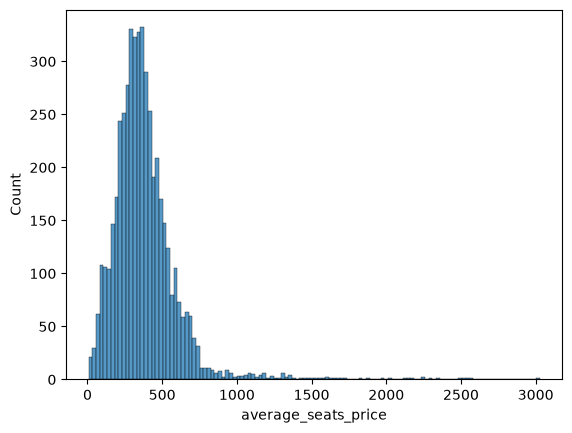

In [22]:
sns.histplot(user_features, x= "average_seats_price")

<Axes: xlabel='age', ylabel='average_seats_price'>

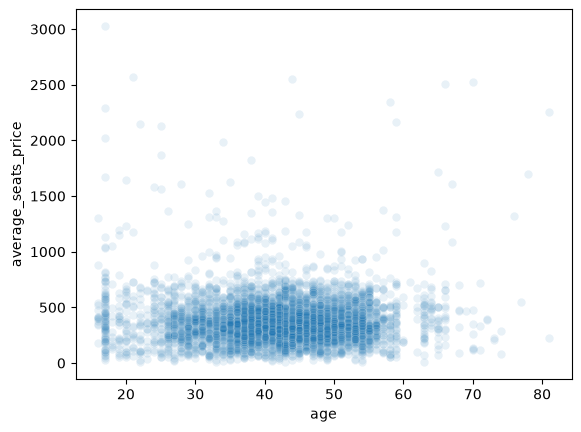

In [23]:
sns.scatterplot(user_features, x="age", y="average_seats_price", alpha=0.1)

(0.0, 8000.0)

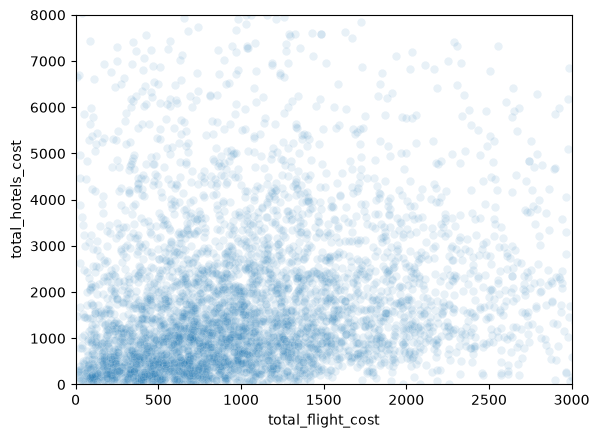

In [24]:
sns.scatterplot(user_features, x="total_flight_cost", y="total_hotels_cost", alpha=0.1)
plt.xlim(0,3000)
plt.ylim(0,8000)

In [25]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_checked_bags,average_seats_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer
0,94883,F,True,False,usa,kansas city,MCI,51,2022,Missouri,...,1.0,932.630000,0.500000,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111
1,101486,F,True,True,usa,tacoma,TCM,50,2022,Washington,...,0.5,180.130000,0.666667,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308
2,101961,F,True,False,usa,boston,BOS,43,2022,Massachusetts,...,0.5,321.533333,0.142857,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944
3,106907,F,True,True,usa,miami,TNT,44,2022,Florida,...,1.0,165.510000,0.000000,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858
4,118043,F,False,True,usa,los angeles,LAX,51,2022,California,...,1.0,445.847222,0.250000,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,49,2023,California,...,0.0,448.535000,0.000000,1.000000,1122.1060,220.00,15.500000,609.885174,8.034557,1.929167
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,0.0,176.675000,1.000000,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,0.5,259.792500,1.000000,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,0.0,579.790000,0.000000,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083


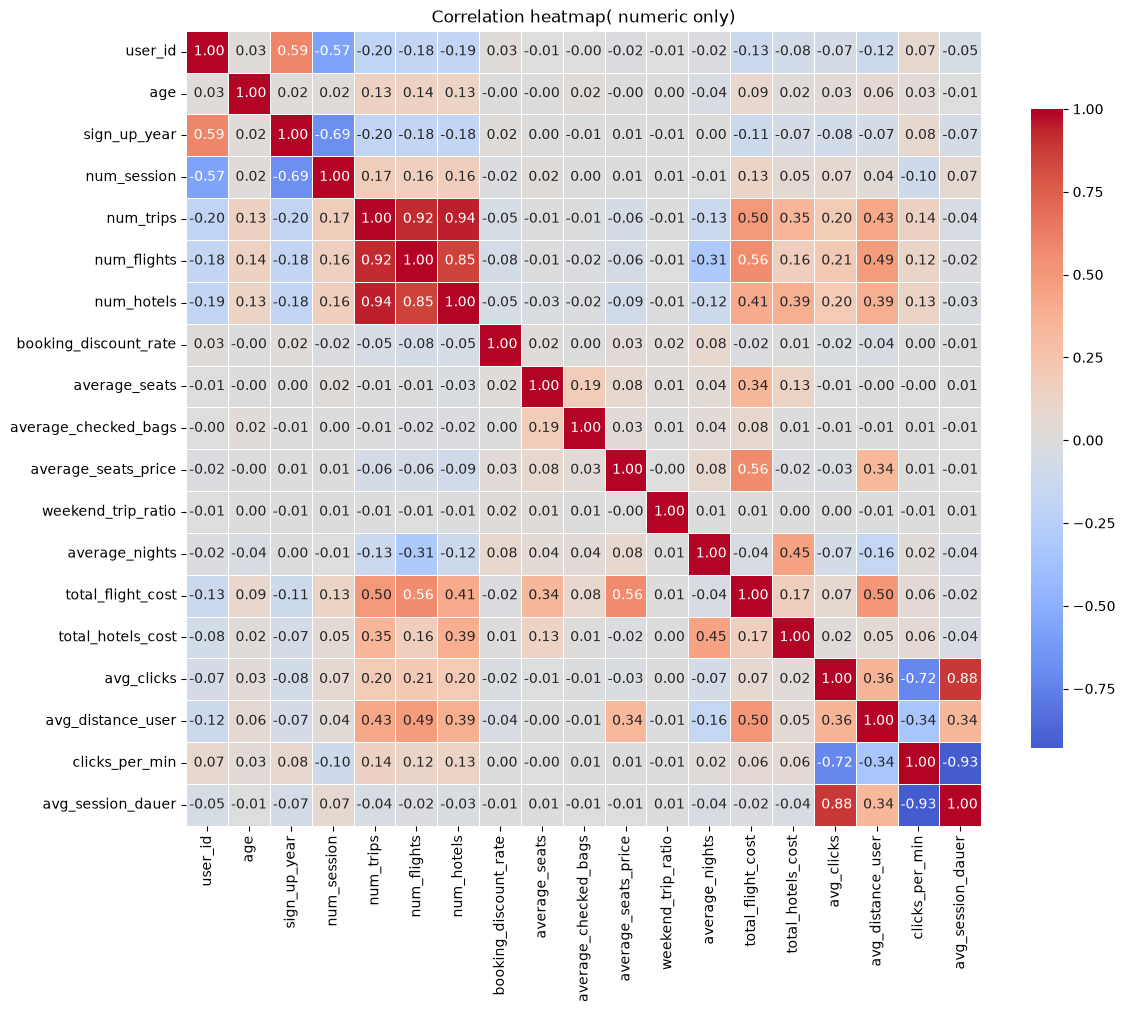

In [26]:
corr = user_features.select_dtypes(include= "number").corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt= ' .2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Correlation heatmap( numeric only)')
plt.tight_layout()
plt.show()

<Axes: xlabel='num_flights', ylabel='total_flight_cost'>

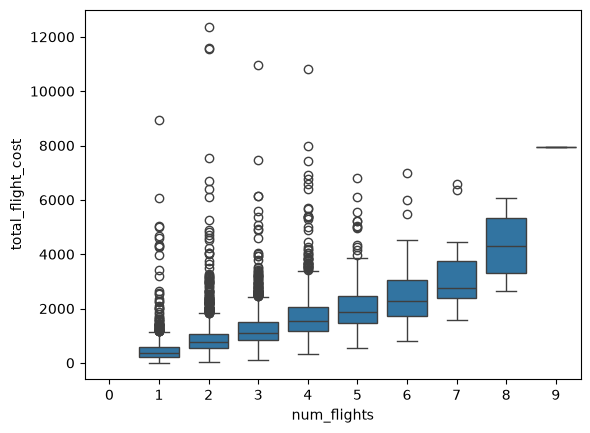

In [27]:
sns.boxplot(user_features, x ="num_flights", y="total_flight_cost")

# Average Duration Stay

In [28]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_checked_bags,average_seats_price,weekend_trip_ratio,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer
0,94883,F,True,False,usa,kansas city,MCI,51,2022,Missouri,...,1.0,932.630000,0.500000,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111
1,101486,F,True,True,usa,tacoma,TCM,50,2022,Washington,...,0.5,180.130000,0.666667,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308
2,101961,F,True,False,usa,boston,BOS,43,2022,Massachusetts,...,0.5,321.533333,0.142857,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944
3,106907,F,True,True,usa,miami,TNT,44,2022,Florida,...,1.0,165.510000,0.000000,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858
4,118043,F,False,True,usa,los angeles,LAX,51,2022,California,...,1.0,445.847222,0.250000,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,49,2023,California,...,0.0,448.535000,0.000000,1.000000,1122.1060,220.00,15.500000,609.885174,8.034557,1.929167
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,0.0,176.675000,1.000000,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,0.5,259.792500,1.000000,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,0.0,579.790000,0.000000,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083


In [29]:
user_features["average_nights"].round().value_counts()

average_nights
2.0     1445
4.0      894
3.0      872
1.0      567
6.0      410
5.0      388
7.0      155
8.0      151
10.0      70
9.0       63
12.0      40
11.0      37
13.0      17
16.0      16
14.0      15
15.0      10
17.0       7
18.0       6
20.0       5
23.0       2
27.0       2
21.0       2
30.0       1
24.0       1
28.0       1
25.0       1
19.0       1
22.0       1
Name: count, dtype: int64

<Axes: xlabel='average_nights', ylabel='Count'>

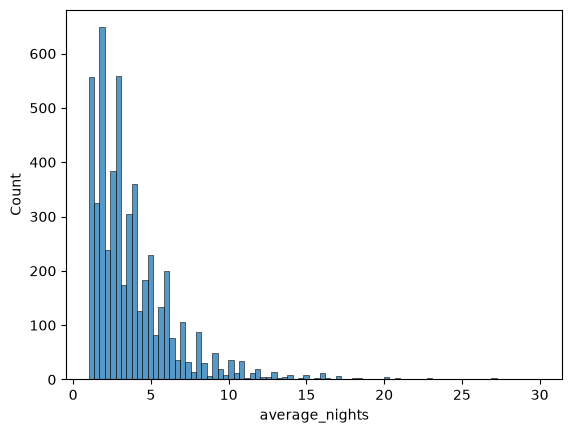

In [30]:
sns.histplot(user_features["average_nights"])

<Axes: xlabel='average_nights', ylabel='Count'>

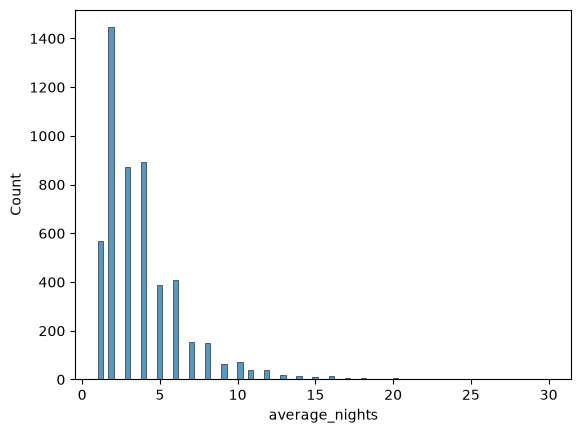

In [31]:
sns.histplot(user_features["average_nights"].round())

Interesting possible **new Group** long stayers after a week

# trips_per_session

In [32]:
user_features["trips_per_session"] = user_features["num_trips"]/user_features["num_session"]

In [33]:
user_features["trips_per_session"].describe()

count    5782.000000
mean        0.319200
std         0.186917
min         0.000000
25%         0.200000
50%         0.333333
75%         0.444444
max         1.000000
Name: trips_per_session, dtype: float64

In [34]:
# 0 → User hatte Sessions, aber keine Trips
# 0.1 → 1 Trip pro 10 Sessions
# 0.5 → 1 Trip pro 2 Sessions
# 1.0 → durchschnittlich 1 Trip pro Session
# >1 → mehrere Trips im Verhältnis zur Anzahl der Sessions

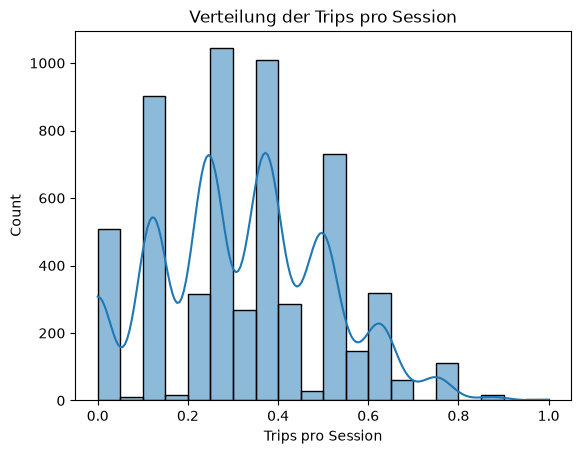

In [35]:
sns.histplot(
    data=user_features,
    x="trips_per_session",
    binwidth=0.05,
    kde=True
)

plt.xlabel("Trips pro Session")
plt.title("Verteilung der Trips pro Session")
plt.show()


In [36]:
user_features["total_spent"] = user_features["total_flight_cost"] + user_features["total_hotels_cost"]

<Axes: xlabel='total_spent', ylabel='Count'>

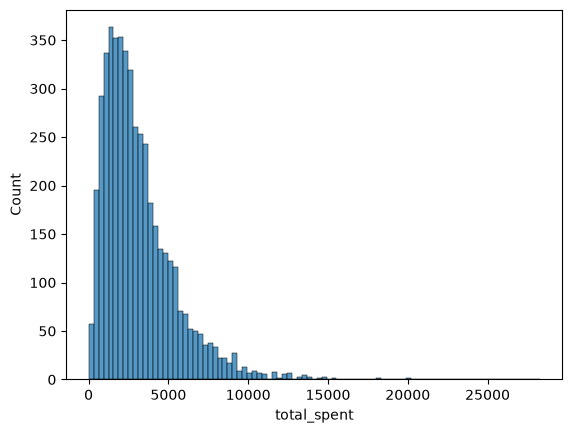

In [37]:
sns.histplot(user_features["total_spent"])

In [38]:
user_features["total_spent"].quantile(0.9)

np.float64(6071.9521)

<Axes: xlabel='booking_discount_rate', ylabel='Count'>

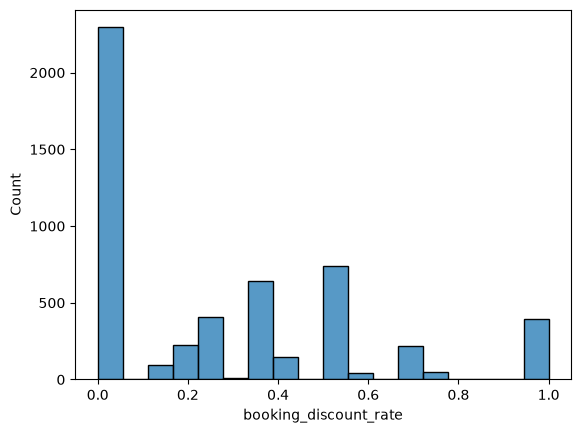

In [39]:
sns.histplot(user_features, x= "booking_discount_rate")

<Axes: xlabel='age', ylabel='Count'>

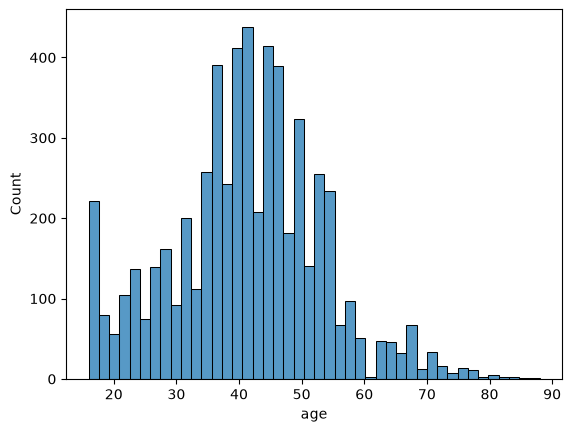

In [40]:
sns.histplot(user_features, x="age")

<Axes: xlabel='average_seats', ylabel='Count'>

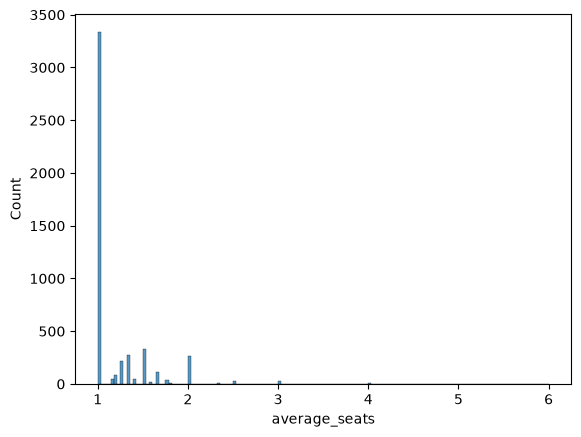

In [41]:
sns.histplot(user_features, x="average_seats")

In [42]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'sign_up_year', 'states',
       'num_session', 'num_trips', 'num_flights', 'num_hotels',
       'booking_discount_rate', 'average_seats', 'average_checked_bags',
       'average_seats_price', 'weekend_trip_ratio', 'average_nights',
       'total_flight_cost', 'total_hotels_cost', 'avg_clicks',
       'avg_distance_user', 'clicks_per_min', 'avg_session_dauer',
       'trips_per_session', 'total_spent'],
      dtype='str')

# Group Building

In [43]:
# - long stayers: avg nights >= 7
# - top spenders: user_features["total_spent"].quantile(0.9)
# - discount buyers, booking_discount_rate > 0.8
# - indecisive conversion rate < 0.2
# - youngs age < 20
# - retired age > 60
# - family travelers average_seats >1.8 and have children

In [44]:
# Priorisierung der Gruppen:

# - long stayers: avg nights >= 7
# - indecisive conversion rate < 0.2
# - top spenders: user_features["total_spent"].quantile(0.9)
# - youngs age < 20
# - retired age > 60
# - discount buyers, booking_discount_rate > 0.8
# - family travelers average_seats >1.8 and have children
# - only Hotel
# - only flight

In [45]:
import numpy as np

In [46]:
user_features["group"] = None

In [47]:
#user_features.loc[(user_features["num_flights"] > 0) & (user_features["num_hotels"]==0),"group"] = "Only flight"

#user_features.loc[(user_features["num_flights"] == 0) & (user_features["num_hotels"] > 0),"group"] = "Only hotel"

#user_features.loc[(user_features["average_seats"] > 1.5) & (user_features["has_children"]),"group"] = "Family Travelers"

#user_features.loc[user_features["booking_discount_rate"] > 0.8, "group"] = "Discount Buyers"

#user_features.loc[user_features["age"] > 60, "group"] = "Retired"

#user_features.loc[user_features["age"] < 20, "group"] = "Young"

#user_features.loc[user_features["total_spent"]>user_features["total_spent"].quantile(0.9), "group"] = "high Spenders"

#user_features.loc[user_features["trips_per_session"]<0.2, "group"] = "Indecisive"

#user_features.loc[user_features["average_nights"]>7, "group"] = "Long Stayers"

### meine Gruppierung

In [48]:
#user_features.loc[(user_features["num_flights"] > 0) & (user_features["num_hotels"]==0),"group"] = "Only flight"

#user_features.loc[(user_features["num_flights"] == 0) & (user_features["num_hotels"] > 0),"group"] = "Only hotel"

user_features.loc[user_features["age"] < 20, "group"] = "Young Travelers"

user_features.loc[user_features["booking_discount_rate"] >=user_features["booking_discount_rate"].quantile(.75),"group"] = "Discount buyers"

user_features.loc[user_features["avg_distance_user"] >= user_features["avg_distance_user"].quantile(0.75), "group"] = "Long-Distance Travelers"

user_features.loc[user_features["average_nights"]>7, "group"] = "Long Stayers"

user_features.loc[(user_features["average_seats"] > 1.5) & (user_features["has_children"]),"group"] = "Family Travelers"

user_features.loc[(user_features["avg_session_dauer"] <= user_features["avg_session_dauer"].median()) &(user_features["clicks_per_min"] >= user_features["clicks_per_min"].quantile(.75)),"group"] = "Quick Decision Makers"

user_features.loc[user_features["total_spent"] >=user_features["total_spent"].quantile(0.75), "group"] = "VIPs"


In [49]:
user_features

,user_id,gender,married,has_children,home_country,home_city,home_airport,age,sign_up_year,states,...,average_nights,total_flight_cost,total_hotels_cost,avg_clicks,avg_distance_user,clicks_per_min,avg_session_dauer,trips_per_session,total_spent,group
0,94883,F,True,False,usa,kansas city,MCI,51,2022,Missouri,...,1.000000,5354.8600,230.00,8.333333,1060.930335,8.042895,1.036111,0.250000,5584.8600,VIPs
1,101486,F,True,True,usa,tacoma,TCM,50,2022,Washington,...,3.333333,351.7425,2277.05,26.153846,2094.397252,2.379286,10.992308,0.230769,2628.7925,Long-Distance Travelers
2,101961,F,True,False,usa,boston,BOS,43,2022,Massachusetts,...,3.285714,1924.2330,2550.40,18.166667,2436.512974,8.049231,2.256944,0.583333,4474.6330,VIPs
3,106907,F,True,True,usa,miami,TNT,44,2022,Florida,...,6.000000,165.5100,2231.00,26.285714,2061.557769,3.142023,8.365858,0.142857,2396.5100,Long-Distance Travelers
4,118043,F,False,True,usa,los angeles,LAX,51,2022,California,...,5.500000,2339.2900,5811.00,16.153846,623.381115,4.274937,3.778733,0.384615,8150.2900,VIPs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5777,780167,F,True,True,usa,los angeles,LAX,49,2023,California,...,1.000000,1122.1060,220.00,15.500000,609.885174,8.034557,1.929167,0.250000,1342.1060,Discount buyers
5778,785186,F,True,True,usa,little rock,LIT,44,2023,Arkansas,...,1.000000,353.3500,291.00,21.625000,263.178203,8.052754,2.685417,0.250000,644.3500,None
5779,792549,F,False,False,usa,kansas city,MCI,45,2023,Missouri,...,4.000000,1039.1700,136.80,14.250000,719.002463,8.000000,1.781250,0.500000,1175.9700,None
5780,811077,F,True,True,usa,knoxville,TYS,44,2023,Tennessee,...,6.000000,579.7900,852.00,13.125000,398.104421,7.944515,1.652083,0.125000,1431.7900,None


In [50]:
user_features.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country',
       'home_city', 'home_airport', 'age', 'sign_up_year', 'states',
       'num_session', 'num_trips', 'num_flights', 'num_hotels',
       'booking_discount_rate', 'average_seats', 'average_checked_bags',
       'average_seats_price', 'weekend_trip_ratio', 'average_nights',
       'total_flight_cost', 'total_hotels_cost', 'avg_clicks',
       'avg_distance_user', 'clicks_per_min', 'avg_session_dauer',
       'trips_per_session', 'total_spent', 'group'],
      dtype='str')

In [51]:
user_features.loc[user_features["group"].isna(), "group"] = "Not assigned"

In [52]:
user_features["group"].value_counts(dropna=False)

group
Not assigned               2017
VIPs                       1200
Long-Distance Travelers     790
Discount buyers             695
Quick Decision Makers       627
Long Stayers                230
Young Travelers             153
Family Travelers             70
Name: count, dtype: int64

In [53]:
user_features.to_csv("data/data_preprocessed/user_features_grouped1.csv", index=False)